In [3]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 12.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 22.6 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [medmnist]/13 [torchvision]]

[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from medmnist import BreastMNIST

os.makedirs("../data", exist_ok=True)       
train = BreastMNIST(split="train", download=True, root="../data")
test  = BreastMNIST(split="test",  download=True, root="../data")
print(train)

100%|██████████| 560k/560k [00:04<00:00, 138kB/s] 

Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 546
    Root location: ../data
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0


In [5]:
X_train_img = train.imgs            
y_train = train.labels.ravel()       

print("Shape of images:", X_train_img.shape)
print("Pixel values from", X_train_img.min(), "to", X_train_img.max())

names = {0: "malignant", 1: "normal / benign"}
for c in [0, 1]:
    print(names[c], ":", (y_train == c).sum(), "images")

Shape of images: (546, 28, 28)
Pixel values from 0 to 255
malignant : 147 images
normal / benign : 399 images


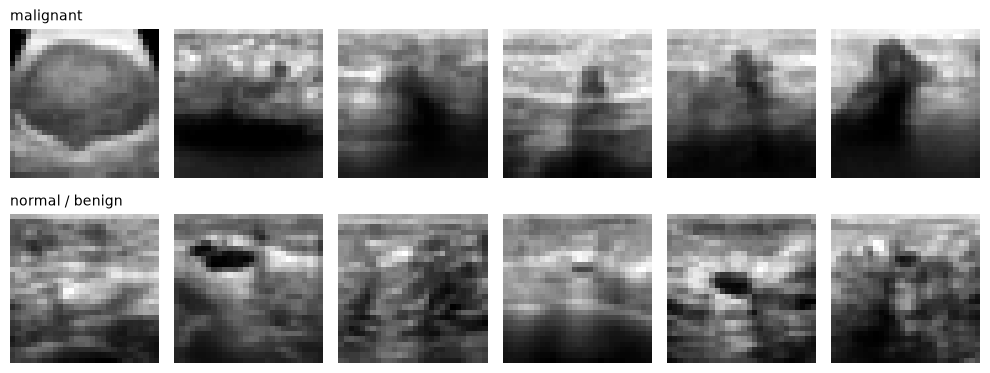

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for row, c in enumerate([0, 1]):
    idx = np.where(y_train == c)[0][:6]         
    for col, i in enumerate(idx):
        axes[row, col].imshow(X_train_img[i], cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_title(names[c], loc="left", fontsize=10)
fig.tight_layout()
os.makedirs("../results", exist_ok=True)
fig.savefig("../results/breastmnist_examples.png", dpi=150)
plt.show()

In [7]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
print("Each image becomes", X_train_flat.shape[1], "numbers")

Each image becomes 784 numbers


100%|██████████| 30.9M/30.9M [02:12<00:00, 233kB/s] 


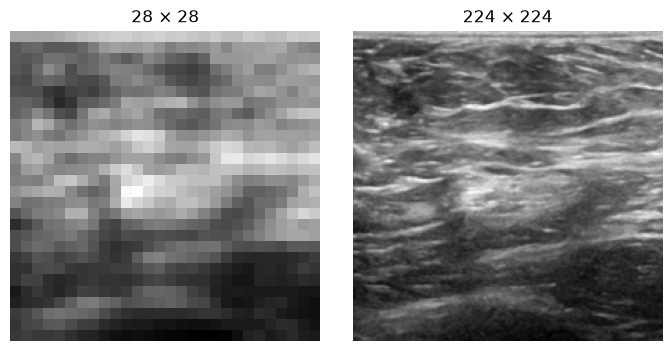

In [8]:
train224 = BreastMNIST(split="train", download=True, root="../data", size=224)

i = 0   # the first image
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(X_train_img[i], cmap="gray");  axes[0].set_title("28 × 28")
axes[1].imshow(train224.imgs[i], cmap="gray"); axes[1].set_title("224 × 224")
for ax in axes: ax.axis("off")
fig.tight_layout()
fig.savefig("../results/breastmnist_28_vs_224.png", dpi=150)
plt.show()

Image features with a pretrained ResNet-18

In [10]:
import torch
from torchvision.models import resnet18, ResNet18_Weights

sets = {}
for split in ["train", "val", "test"]:
    ds = BreastMNIST(split=split, download=True, root="../data", size=224)
    sets[split] = (ds.imgs, ds.labels.ravel())
    y = sets[split][1]
    print(f"{split:5s}: {len(y)} images | malignant = {(y == 0).sum()}, normal/benign = {(y == 1).sum()}")

train: 546 images | malignant = 147, normal/benign = 399
val  : 78 images | malignant = 21, normal/benign = 57
test : 156 images | malignant = 42, normal/benign = 114


In [11]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)   
model.fc = torch.nn.Identity()                       # removal of the last layer
model.eval()                                        


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/jynad/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 25.7MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [12]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def extract(imgs, batch_size=64):
    feats = []
    with torch.no_grad():                                                   
        for start in range(0, len(imgs), batch_size):                       
            x = torch.from_numpy(imgs[start:start + batch_size]).float() / 255.0   
            x = x.unsqueeze(1).repeat(1, 3, 1, 1)                            
            x = (x - MEAN) / STD                                             
            feats.append(model(x).numpy())                                  
    return np.concatenate(feats)

In [13]:
path = "../data/features/breastmnist224_resnet18.npz"

if os.path.exists(path):
    features = dict(np.load(path))          
    print("Loaded saved features")
else:
    features = {}
    for split, (imgs, y) in sets.items():
        features[f"X_{split}"] = extract(imgs)
        features[f"y_{split}"] = y
    os.makedirs("../data/features", exist_ok=True)
    np.savez(path, **features)
    print("Extracted and saved features")

for split in ["train", "val", "test"]:
    print(split, features[f"X_{split}"].shape)

Extracted and saved features
train (546, 512)
val (78, 512)
test (156, 512)


In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.algorithms import QSVC
import pandas as pd

X_train, y_train = features["X_train"], features["y_train"]
X_val,   y_val   = features["X_val"],   features["y_val"]
X_test,  y_test  = features["X_test"],  features["y_test"]

n_qubits = 4
scaler = StandardScaler().fit(X_train)
pca = PCA(n_components=n_qubits, random_state=0).fit(scaler.transform(X_train))
to_angle = MinMaxScaler(feature_range=(0, np.pi)).fit(pca.transform(scaler.transform(X_train)))
prepare = lambda A: to_angle.transform(pca.transform(scaler.transform(A)))

Xtr, Xva, Xte = prepare(X_train), prepare(X_val), prepare(X_test)
print("Train", Xtr.shape, "Val", Xva.shape, "Test", Xte.shape)
print("Information kept by", n_qubits, "numbers:", round(pca.explained_variance_ratio_.sum(), 3))

Train (546, 4) Val (78, 4) Test (156, 4)
Information kept by 4 numbers: 0.29


In [15]:
x = ParameterVector("x", n_qubits)
simple_circuit = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    simple_circuit.ry(x[i], i)
entangled_circuit = zz_feature_map(n_qubits, reps=2)

def make_model(name, C):
    if name == "Logistic Regression":
        return LogisticRegression(C=C, class_weight="balanced", max_iter=1000)
    if name == "Classical SVM":
        return SVC(kernel="rbf", C=C, class_weight="balanced")
    if name == "Quantum SVM (simple)":
        return QSVC(quantum_kernel=FidelityStatevectorKernel(feature_map=simple_circuit), C=C, class_weight="balanced")
    if name == "Quantum SVM (entangled)":
        return QSVC(quantum_kernel=FidelityStatevectorKernel(feature_map=entangled_circuit), C=C, class_weight="balanced")

model_names = ["Logistic Regression", "Classical SVM", "Quantum SVM (simple)", "Quantum SVM (entangled)"]
C_options = [0.1, 1, 10]

In [16]:
best_C = {}
for name in model_names:
    scores = {}
    for C in C_options:
        model = make_model(name, C).fit(Xtr, y_train)                    
        scores[C] = balanced_accuracy_score(y_val, model.predict(Xva))   
    best_C[name] = max(scores, key=scores.get)                           # keep the best C
    print(f"{name:25s} validation: { {c: round(s, 3) for c, s in scores.items()} } -> chosen C = {best_C[name]}")

Logistic Regression       validation: {0.1: 0.744, 1: 0.753, 10: 0.762} -> chosen C = 10
Classical SVM             validation: {0.1: 0.791, 1: 0.791, 10: 0.791} -> chosen C = 0.1
Quantum SVM (simple)      validation: {0.1: 0.727, 1: 0.791, 10: 0.791} -> chosen C = 1
Quantum SVM (entangled)   validation: {0.1: 0.665, 1: 0.667, 10: 0.669} -> chosen C = 10


In [17]:
def bootstrap_ci(y_true, y_pred, metric, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    values = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)                  # pick n test images at random, repeats allowed
        values.append(metric(y_true[idx], y_pred[idx]))
    return np.percentile(values, [2.5, 97.5])      

sensitivity = lambda yt, yp: recall_score(yt, yp, pos_label=0)   # 0 = malignant

rows = []
for name in model_names:
    model = make_model(name, best_C[name]).fit(Xtr, y_train)
    pred = model.predict(Xte)
    low, high = bootstrap_ci(y_test, pred, balanced_accuracy_score)
    rows.append({
        "model": name,
        "C": best_C[name],
        "accuracy": accuracy_score(y_test, pred),
        "balanced accuracy": balanced_accuracy_score(y_test, pred),
        "bal. acc. 95% CI": f"[{low:.3f}, {high:.3f}]",
        "sensitivity": sensitivity(y_test, pred),
    })

results = pd.DataFrame(rows).round(3)
print(results.to_string(index=False))
os.makedirs("../results", exist_ok=True)
results.to_csv("../results/exp2_breastmnist_test.csv", index=False)

                  model    C  accuracy  balanced accuracy bal. acc. 95% CI  sensitivity
    Logistic Regression 10.0     0.744              0.742   [0.661, 0.821]        0.738
          Classical SVM  0.1     0.795              0.762   [0.679, 0.842]        0.690
   Quantum SVM (simple)  1.0     0.776              0.764   [0.678, 0.836]        0.738
Quantum SVM (entangled) 10.0     0.699              0.659   [0.570, 0.742]        0.571


In [ ]:
scaler_full = StandardScaler().fit(X_train)
Ftr, Fva, Fte = scaler_full.transform(X_train), scaler_full.transform(X_val), scaler_full.transform(X_test)

ceiling_rows = []
for name in ["Logistic Regression", "Classical SVM"]:
    def build(C):
        if name == "Logistic Regression":
            return LogisticRegression(C=C, class_weight="balanced", max_iter=5000)
        return SVC(kernel="rbf", C=C, class_weight="balanced")

    val_scores = {C: balanced_accuracy_score(y_val, build(C).fit(Ftr, y_train).predict(Fva)) for C in C_options}
    C = max(val_scores, key=val_scores.get)                
    pred = build(C).fit(Ftr, y_train).predict(Fte)         
    low, high = bootstrap_ci(y_test, pred, balanced_accuracy_score)
    ceiling_rows.append({"model": name + " (all 512)", "C": C,
                         "balanced accuracy": balanced_accuracy_score(y_test, pred),
                         "bal. acc. 95% CI": f"[{low:.3f}, {high:.3f}]",
                         "sensitivity": sensitivity(y_test, pred)})

ceiling = pd.DataFrame(ceiling_rows).round(3)
print(ceiling.to_string(index=False))

                        model  C  balanced accuracy bal. acc. 95% CI  sensitivity
Logistic Regression (all 512)  1              0.796   [0.715, 0.864]        0.714
      Classical SVM (all 512) 10              0.828   [0.755, 0.894]        0.690


In [ ]:
def make_model_n(name, C, n):
    if name == "Logistic Regression":
        return LogisticRegression(C=C, class_weight="balanced", max_iter=1000)
    if name == "Classical SVM":
        return SVC(kernel="rbf", C=C, class_weight="balanced")
    if name == "Quantum SVM (simple)":
        x = ParameterVector("x", n)
        qc = QuantumCircuit(n)
        for i in range(n):
            qc.ry(x[i], i)
        return QSVC(quantum_kernel=FidelityStatevectorKernel(feature_map=qc), C=C, class_weight="balanced")
    if name == "Quantum SVM (entangled)":
        return QSVC(quantum_kernel=FidelityStatevectorKernel(feature_map=zz_feature_map(n, reps=2)), C=C, class_weight="balanced")

sweep_rows = []
for n in [2, 4, 6, 8]:
    # prepare n numbers per image 
    sc = StandardScaler().fit(X_train)
    pc = PCA(n_components=n, random_state=0).fit(sc.transform(X_train))
    ang = MinMaxScaler(feature_range=(0, np.pi)).fit(pc.transform(sc.transform(X_train)))
    prep = lambda A: ang.transform(pc.transform(sc.transform(A)))
    Xtr_n, Xva_n, Xte_n = prep(X_train), prep(X_val), prep(X_test)
    kept = pc.explained_variance_ratio_.sum()

    for name in model_names:
        val_scores = {C: balanced_accuracy_score(y_val, make_model_n(name, C, n).fit(Xtr_n, y_train).predict(Xva_n))
                      for C in C_options}
        C = max(val_scores, key=val_scores.get)                       
        pred = make_model_n(name, C, n).fit(Xtr_n, y_train).predict(Xte_n)   
        low, high = bootstrap_ci(y_test, pred, balanced_accuracy_score)
        sweep_rows.append({"qubits": n, "info kept": kept, "model": name, "C": C,
                           "balanced accuracy": balanced_accuracy_score(y_test, pred),
                           "ci_low": low, "ci_high": high,
                           "sensitivity": sensitivity(y_test, pred)})
    print("Done:", n, "qubits | information kept:", round(kept, 3))

sweep = pd.DataFrame(sweep_rows)
print(sweep.pivot(index="qubits", columns="model", values="balanced accuracy").round(3).to_string())

Done: 2 qubits | information kept: 0.197
Done: 4 qubits | information kept: 0.29
Done: 6 qubits | information kept: 0.351
Done: 8 qubits | information kept: 0.398
model   Classical SVM  Logistic Regression  Quantum SVM (entangled)  Quantum SVM (simple)
qubits                                                                                   
2               0.702                0.566                    0.667                 0.679
4               0.762                0.742                    0.659                 0.764
6               0.798                0.786                    0.625                 0.817
8               0.827                0.796                    0.500                 0.852


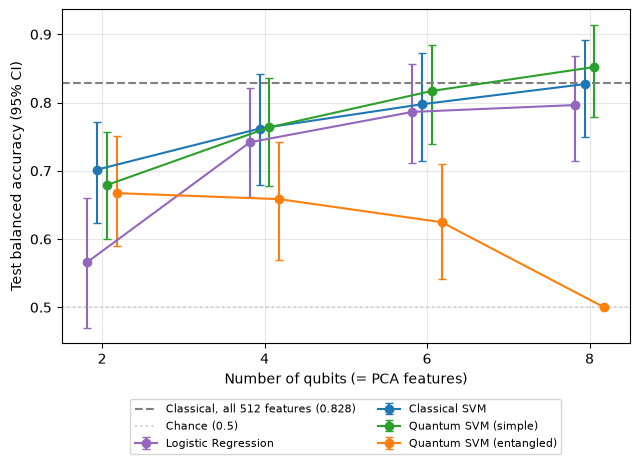

In [20]:
colors = {"Logistic Regression": "tab:purple", "Classical SVM": "tab:blue",
          "Quantum SVM (simple)": "tab:green", "Quantum SVM (entangled)": "tab:orange"}

fig, ax = plt.subplots(figsize=(6.5, 4.8))
for k, name in enumerate(model_names):
    g = sweep[sweep.model == name]
    xs = g["qubits"] + (k - 1.5) * 0.12          # nudge sideways so error bars don't overlap
    ax.errorbar(xs, g["balanced accuracy"],
                yerr=[g["balanced accuracy"] - g["ci_low"], g["ci_high"] - g["balanced accuracy"]],
                marker="o", capsize=3, label=name, color=colors[name])

best_ceiling = ceiling["balanced accuracy"].max()
ax.axhline(best_ceiling, linestyle="--", color="gray", label=f"Classical, all 512 features ({best_ceiling:.3f})")
ax.axhline(0.5, linestyle=":", color="lightgray", label="Chance (0.5)")
ax.set_xticks([2, 4, 6, 8])
ax.set_xlabel("Number of qubits (= PCA features)")
ax.set_ylabel("Test balanced accuracy (95% CI)")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()

fig.savefig("../results/exp2_qubit_sweep.png", dpi=150)
sweep.round(4).to_csv("../results/exp2_qubit_sweep.csv", index=False)
ceiling.to_csv("../results/exp2_ceiling.csv", index=False)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from scipy.stats import wilcoxon

X_all = np.concatenate([features["X_train"], features["X_val"], features["X_test"]])
y_all = np.concatenate([features["y_train"], features["y_val"], features["y_test"]])
print("All images:", X_all.shape, "| malignant:", (y_all == 0).sum(), "| normal/benign:", (y_all == 1).sum())

def split_70_10_20(seed):
    X_rest, X_te, y_rest, y_te = train_test_split(X_all, y_all, test_size=0.20, stratify=y_all, random_state=seed)
    X_tr, X_va, y_tr, y_va = train_test_split(X_rest, y_rest, test_size=0.125, stratify=y_rest, random_state=seed)
    return X_tr, X_va, X_te, y_tr, y_va, y_te

def quantum_circuit(kind, n):
    if kind == "simple":
        x = ParameterVector("x", n)
        qc = QuantumCircuit(n)
        for i in range(n):
            qc.ry(x[i], i)
        return qc
    return zz_feature_map(n, reps=2)

def tune_and_test(make, A_tr, A_va, A_te, y_tr, y_va, y_te):
    val = {C: balanced_accuracy_score(y_va, make(C).fit(A_tr, y_tr).predict(A_va)) for C in C_options}
    C = max(val, key=val.get)                               
    pred = make(C).fit(A_tr, y_tr).predict(A_te)            
    return balanced_accuracy_score(y_te, pred), sensitivity(y_te, pred)

All images: (780, 512) | malignant: 210 | normal/benign: 570


In [22]:
rows = []
for seed in range(10):
    X_tr, X_va, X_te, y_tr, y_va, y_te = split_70_10_20(seed)

    # Ceiling: classical SVM on all 512 numbers
    sc_full = StandardScaler().fit(X_tr)
    ba, se = tune_and_test(lambda C: SVC(kernel="rbf", C=C, class_weight="balanced"),
                           sc_full.transform(X_tr), sc_full.transform(X_va), sc_full.transform(X_te),
                           y_tr, y_va, y_te)
    rows.append({"split": seed, "qubits": "all 512", "model": "Classical SVM", "balanced accuracy": ba, "sensitivity": se})

    for n in [4, 8]:
        # squeeze to n numbers (learned from train only)
        sc = StandardScaler().fit(X_tr)
        pc = PCA(n_components=n, random_state=0).fit(sc.transform(X_tr))
        ang = MinMaxScaler(feature_range=(0, np.pi)).fit(pc.transform(sc.transform(X_tr)))
        prep = lambda A: ang.transform(pc.transform(sc.transform(A)))
        A_tr, A_va, A_te = prep(X_tr), prep(X_va), prep(X_te)

        # classical models
        for name, make in [("Logistic Regression", lambda C: LogisticRegression(C=C, class_weight="balanced", max_iter=1000)),
                           ("Classical SVM",       lambda C: SVC(kernel="rbf", C=C, class_weight="balanced"))]:
            ba, se = tune_and_test(make, A_tr, A_va, A_te, y_tr, y_va, y_te)
            rows.append({"split": seed, "qubits": n, "model": name, "balanced accuracy": ba, "sensitivity": se})

        # quantum models: build the similarity table ONCE, reuse for every C
        for kind, name in [("simple", "Quantum SVM (simple)"), ("entangled", "Quantum SVM (entangled)")]:
            kernel = FidelityStatevectorKernel(feature_map=quantum_circuit(kind, n))
            K_tr = kernel.evaluate(A_tr)            # train vs train
            K_va = kernel.evaluate(A_va, A_tr)      # validation vs train
            K_te = kernel.evaluate(A_te, A_tr)      # test vs train
            ba, se = tune_and_test(lambda C: SVC(kernel="precomputed", C=C, class_weight="balanced"),
                                   K_tr, K_va, K_te, y_tr, y_va, y_te)
            rows.append({"split": seed, "qubits": n, "model": name, "balanced accuracy": ba, "sensitivity": se})

    print(f"Split {seed} done")

robust = pd.DataFrame(rows)
summary = robust.groupby(["qubits", "model"])[["balanced accuracy", "sensitivity"]].agg(["mean", "std"]).round(3)
print(summary.to_string())

Split 0 done
Split 1 done
Split 2 done
Split 3 done
Split 4 done
Split 5 done
Split 6 done
Split 7 done
Split 8 done
Split 9 done
                                balanced accuracy        sensitivity       
                                             mean    std        mean    std
qubits  model                                                              
4       Classical SVM                       0.743  0.038       0.702  0.047
        Logistic Regression                 0.734  0.042       0.760  0.083
        Quantum SVM (entangled)             0.616  0.046       0.479  0.104
        Quantum SVM (simple)                0.735  0.043       0.724  0.082
8       Classical SVM                       0.798  0.029       0.757  0.029
        Logistic Regression                 0.783  0.043       0.783  0.076
        Quantum SVM (entangled)             0.503  0.006       0.007  0.016
        Quantum SVM (simple)                0.807  0.034       0.783  0.053
all 512 Classical SVM             

In [23]:
for n in [4, 8]:
    table = robust[robust.qubits == n].pivot(index="split", columns="model", values="balanced accuracy")
    for other in ["Logistic Regression", "Quantum SVM (simple)", "Quantum SVM (entangled)"]:
        stat, p = wilcoxon(table[other], table["Classical SVM"], zero_method="zsplit")
        diff = (table[other] - table["Classical SVM"]).mean()
        print(f"{n} qubits | {other:25s} vs Classical SVM: mean difference = {diff:+.3f}, p = {p:.3f}")

robust.round(4).to_csv("../results/exp2_robustness_10_splits.csv", index=False)

4 qubits | Logistic Regression       vs Classical SVM: mean difference = -0.009, p = 0.477
4 qubits | Quantum SVM (simple)      vs Classical SVM: mean difference = -0.008, p = 0.264
4 qubits | Quantum SVM (entangled)   vs Classical SVM: mean difference = -0.128, p = 0.002
8 qubits | Logistic Regression       vs Classical SVM: mean difference = -0.015, p = 0.322
8 qubits | Quantum SVM (simple)      vs Classical SVM: mean difference = +0.010, p = 0.152
8 qubits | Quantum SVM (entangled)   vs Classical SVM: mean difference = -0.295, p = 0.002
